# **Bioinformatics Project - Computational Drug Discovery Regression Models with Random Forest**

## Import libraries

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## Load the data set

In [ ]:
df = pd.read_csv('bioactivitiyvv.csv')

In [ ]:
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.136677
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.698970
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.356547
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.508638
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.920819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.543634
1021,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.636388
1022,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.792904
1023,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.972650


## Input features

data set contains 881 input features and 1 output variable (pIC50 values).

## Input features

In [ ]:
X = df.drop('pIC50', axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1021,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1022,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1023,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X.to_csv('bioact.csv', index=False)

## Output features

In [ ]:
Y = df.pIC50
Y

0       8.136677
1       8.698970
2       6.356547
3       7.508638
4       8.920819
          ...   
1020    7.543634
1021    7.636388
1022    6.792904
1023    6.972650
1024    7.027334
Name: pIC50, Length: 1025, dtype: float64

## **Let's examine the data dimension**

In [ ]:
X.shape

(1025, 881)

In [ ]:
Y.shape

(1025,)

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))    
X = selection.fit_transform(X)

In [ ]:
X.shape

(1025, 173)

## **Data split (80/20 ratio)**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [ ]:
X_train.shape, Y_train.shape

((820, 173), (820,))

In [ ]:
X_test.shape, Y_test.shape

((205, 173), (205,))

# **Building a Regression Model using Random Forest**

In [ ]:
import numpy as np

In [ ]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)
r2 = model.score(X_test, Y_test)
r2

0.29611796061117257

In [ ]:
Y_pred = model.predict(X_test)

## Scatter Plot of Experimental vs Predicted pIC50 Values

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


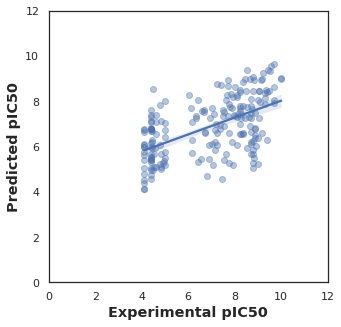

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(Y_test, Y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show
plt.savefig('scatter_plot.pdf')

In [ ]:
! zip -r results.zip . -i *.csv *.pdf

  adding: scatter_plot.pdf (deflated 26%)
  adding: bioact.csv (deflated 95%)
  adding: bioactivitiyvv.csv (deflated 95%)
